# **ARIMA modeling pipeline**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore") # Suppress warnings for cleaner output

In [2]:
# --- Step 1: Load Dataset (from TSDL/R repository) ---
dataset = sm.datasets.get_rdataset("AirPassengers")
df = dataset.data
# Create a proper datetime index
df['time'] = pd.date_range(start='1949-01-01', periods=len(df), freq='MS')
df.set_index('time', inplace=True)
series = df['value']

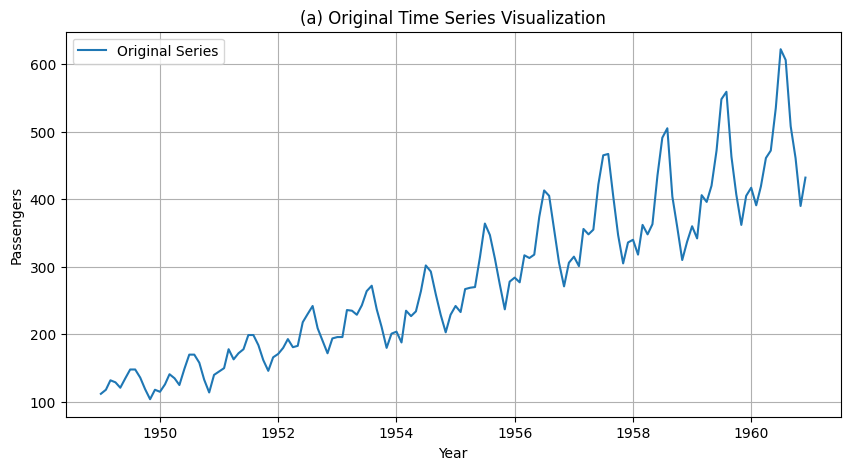

In [3]:
# ==========================================
# (a) Time Series Visualization
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(series, label='Original Series')
plt.title("(a) Original Time Series Visualization")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# ==========================================
# (b) Stationarity Testing (ADF Test)
# ==========================================
def adf_test(timeseries, title):
    print(f"\n--- ADF Test: {title} ---")
    result = adfuller(timeseries.dropna(), autolag='AIC')
    labels = ['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations']
    out = pd.Series(result[0:4], index=labels)
    print(out)
    if result[1] <= 0.05:
        print("Result: Series is STATIONARY")
    else:
        print("Result: Series is NON-STATIONARY")

adf_test(series, "Original Data")


--- ADF Test: Original Data ---
Test Statistic              0.815369
p-value                     0.991880
#Lags Used                 13.000000
Number of Observations    130.000000
dtype: float64
Result: Series is NON-STATIONARY


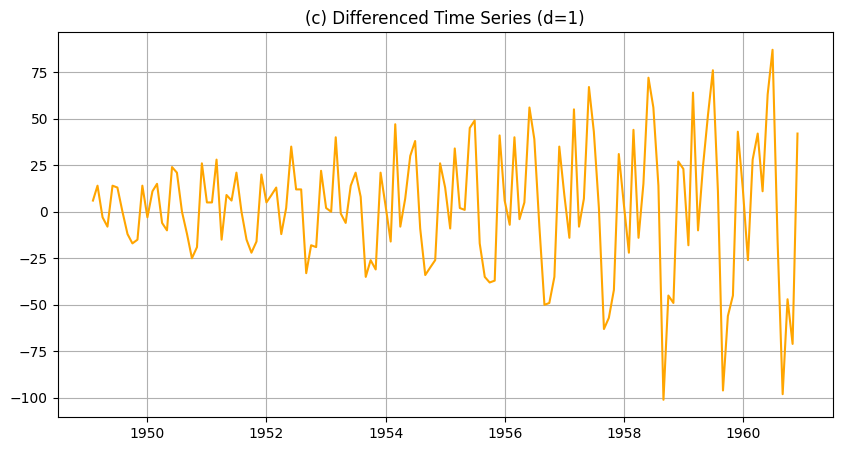

In [5]:
# ==========================================
# (c) Differencing
# ==========================================
# 1st Order Differencing to remove trend
series_diff = series.diff().dropna()

# Plot Differenced Data
plt.figure(figsize=(10, 5))
plt.plot(series_diff, color='orange', label='1st Order Differencing')
plt.title("(c) Differenced Time Series (d=1)")
plt.grid(True)
plt.show()


--- ADF Test: Differenced Data ---
Test Statistic             -2.829267
p-value                     0.054213
#Lags Used                 12.000000
Number of Observations    130.000000
dtype: float64
Result: Series is NON-STATIONARY


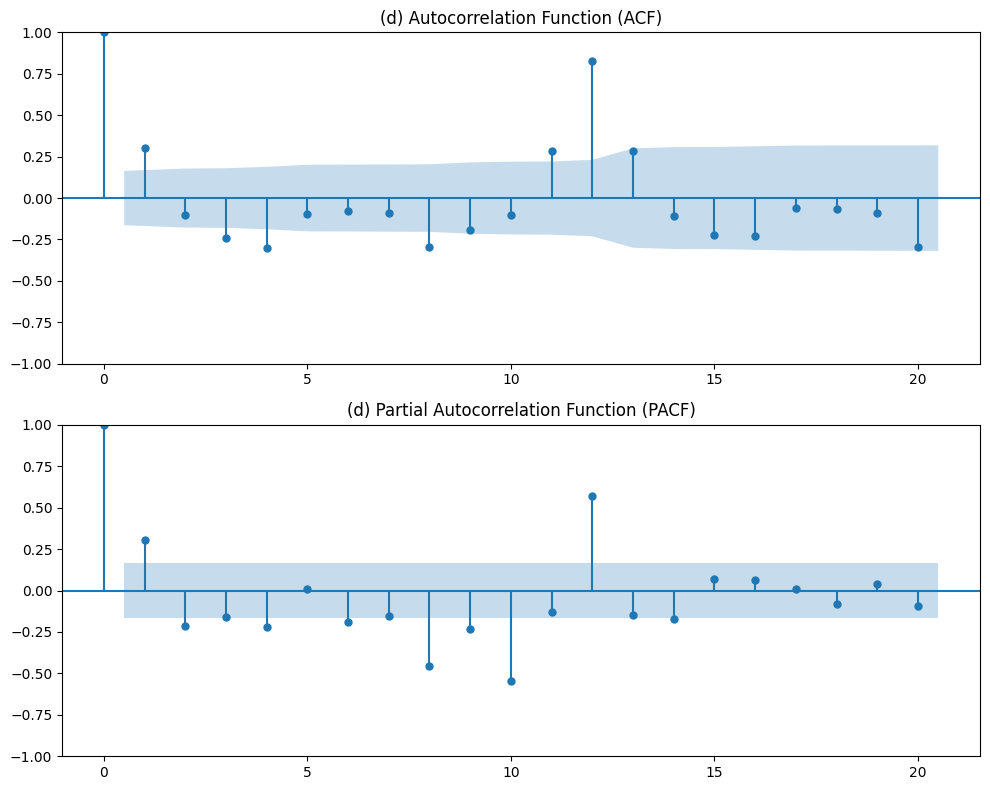

In [6]:
# Re-test Stationarity
adf_test(series_diff, "Differenced Data")

# ==========================================
# (d) ACF/PACF Analysis
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(series_diff, ax=ax1, lags=20)
ax1.set_title("(d) Autocorrelation Function (ACF)")
plot_pacf(series_diff, ax=ax2, lags=20, method='ywm')
ax2.set_title("(d) Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# (e) ARIMA Model Fitting
# ==========================================
# Based on ACF/PACF, we select p and q. 
# (For this demo, we select ARIMA(2,1,2) as a general fit)
p, d, q = 2, 1, 2

print(f"\n--- Fitting ARIMA({p},{d},{q}) Model ---")
model = ARIMA(series, order=(p, d, q))
model_fit = model.fit()
# Print Model Summary
print(model_fit.summary())


--- Fitting ARIMA(2,1,2) Model ---
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Sat, 22 Nov 2025   AIC                           1353.347
Time:                        13:16:34   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.061      0.000       1.645       1.725
ar.L2         -0.9549      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1

In [8]:
# ==========================================
# (f) Forecasting Next 10 Data Points
# ==========================================
forecast_steps = 10
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast_vals = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

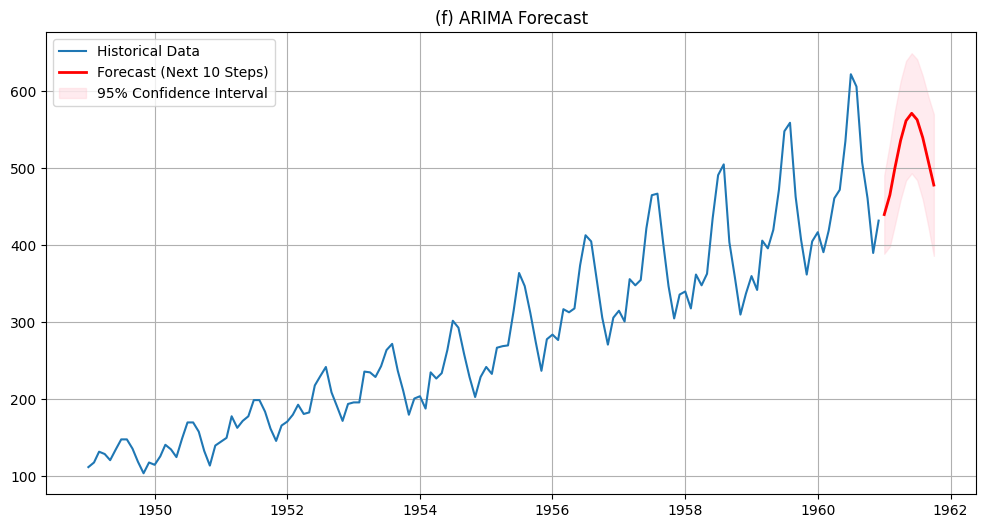


Forecasted Values:
1961-01-01    439.854443
1961-02-01    465.295971
1961-03-01    500.665752
1961-04-01    535.971811
1961-05-01    561.690469
1961-06-01    571.314958
1961-07-01    562.974922
1961-08-01    539.731775
1961-09-01    508.529990
1961-10-01    478.147981
Freq: MS, Name: predicted_mean, dtype: float64


In [9]:
# Plotting the Forecast
plt.figure(figsize=(12, 6))
plt.plot(series, label='Historical Data')
plt.plot(forecast_vals.index, forecast_vals, color='red', label='Forecast (Next 10 Steps)', linewidth=2)
plt.fill_between(forecast_vals.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title("(f) ARIMA Forecast")
plt.legend()
plt.grid(True)
plt.show()

print("\nForecasted Values:")
print(forecast_vals)